In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
gas = pd.read_csv("Data/austin_gas_full.csv")
gas["date"] = pd.to_datetime(gas["date"])
gas = gas.sort_values("date").reset_index(drop=True)

        date  gas_price
0 2021-04-13      2.505
1 2021-04-14      2.509
2 2021-04-15      2.504
3 2021-04-16      2.499
4 2021-04-17      2.499
           date  gas_price
1537 2026-04-08      3.959
1538 2026-04-09      3.944
1539 2026-04-10      3.921
1540 2026-04-11      3.893
1541 2026-04-12      3.880
<class 'pandas.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1542 non-null   datetime64[us]
 1   gas_price  1542 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 24.2 KB
None
                             date    gas_price
count                        1542  1542.000000
mean   2023-10-17 21:20:18.677042     2.982424
min           2021-04-13 00:00:00     2.243000
25%           2022-07-27 06:00:00     2.695250
50%           2023-10-20 12:00:00     2.868000
75%           2025-01-14 18:00:00     3.145000
max           202

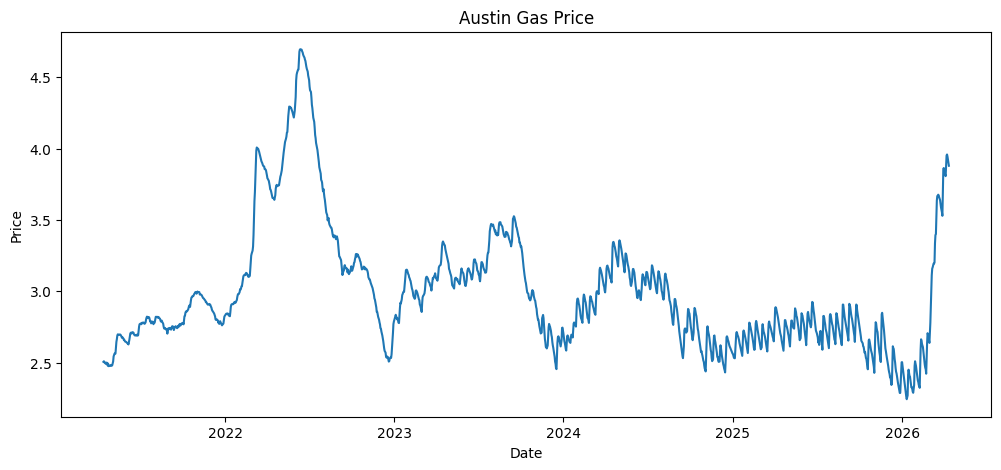

In [9]:
print(gas.head())
print(gas.tail())
print(gas.info())
print(gas.describe())

plt.figure(figsize=(12, 5))
plt.plot(gas["date"], gas["gas_price"])
plt.title("Austin Gas Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [5]:
wti = pd.read_csv("Data/DCOILWTICO.csv")

wti["observation_date"] = pd.to_datetime(wti["observation_date"])
wti["DCOILWTICO"] = pd.to_numeric(wti["DCOILWTICO"], errors="coerce")

wti = wti.sort_values("observation_date").reset_index(drop=True)

# replace missing values
wti["DCOILWTICO"] = wti["DCOILWTICO"].interpolate(method="linear")

# rename
wti = wti.rename(columns={
    "observation_date": "date",
    "DCOILWTICO": "wti"
})

print(wti.head())
print(wti.tail())
print(wti.isna().sum())

        date    wti
0 2000-04-06  25.51
1 2000-04-07  24.97
2 2000-04-10  23.91
3 2000-04-11  24.17
4 2000-04-12  25.49
           date     wti
6778 2026-03-31  102.86
6779 2026-04-01  101.90
6780 2026-04-02  113.23
6781 2026-04-03  113.62
6782 2026-04-06  114.01
date    0
wti     0
dtype: int64


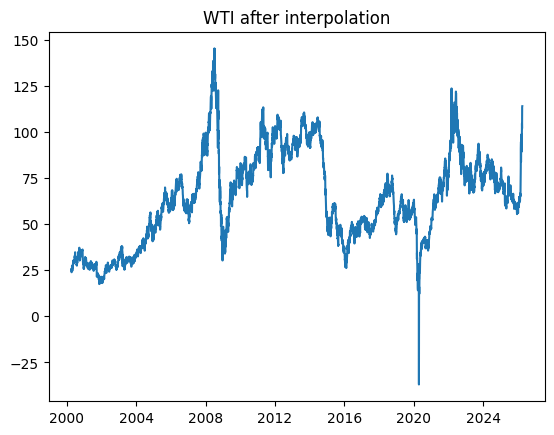

In [6]:
plt.plot(wti["date"], wti["wti"])
plt.title("WTI after interpolation")
plt.show()

In [7]:
# Austin gas
gas_weekly = (
    gas.set_index("date")
    .resample("W-MON")["gas_price"]
    .mean()
    .reset_index()
)
gas_weekly = gas_weekly.rename(columns={"gas_price": "austin_gas"})

# WTI
wti_weekly = (
    wti.set_index("date")
    .resample("W-MON")["wti"]
    .mean()
    .reset_index()
)

In [9]:
df = pd.merge(gas_weekly, wti_weekly, on="date", how="inner")
df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.tail())
print(df.shape)

        date  austin_gas     wti
0 2021-04-19    2.501167  62.652
1 2021-04-26    2.486500  61.920
2 2021-05-03    2.479333  63.960
3 2021-05-10    2.549000  65.192
4 2021-05-17    2.680833  65.330
          date  austin_gas      wti
255 2026-03-09    3.015833   83.072
256 2026-03-16    3.286833   91.598
257 2026-03-23    3.663667   95.256
258 2026-03-30    3.582167   97.364
259 2026-04-06    3.838500  109.124
(260, 3)


In [10]:
print(df["date"].diff().value_counts())

date
7 days    259
Name: count, dtype: int64


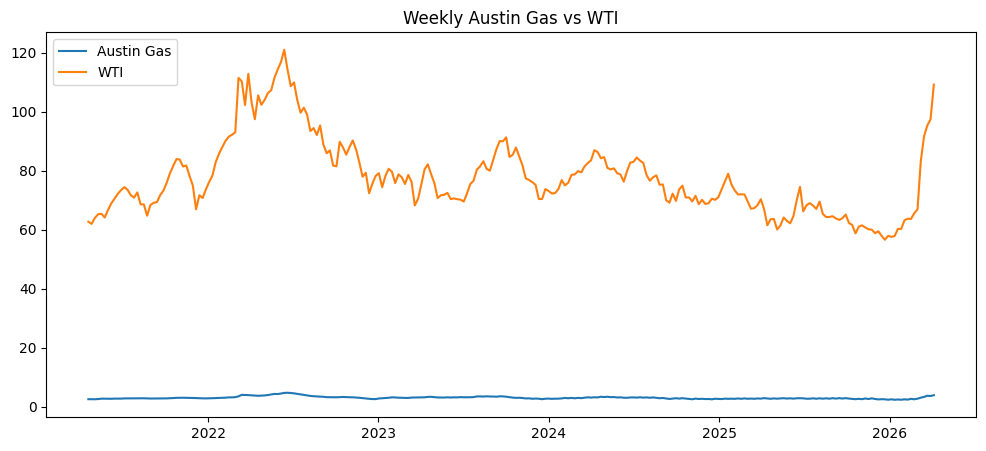

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["austin_gas"], label="Austin Gas")
plt.plot(df["date"], df["wti"], label="WTI")
plt.legend()
plt.title("Weekly Austin Gas vs WTI")
plt.show()

In [12]:
from statsmodels.tsa.stattools import grangercausalitytests

# first diff
df["d_gas"] = df["austin_gas"].diff()
df["d_wti"] = df["wti"].diff()

# drop missing values
gc_df = df[["d_gas", "d_wti"]].dropna()

# WTI → Gas
print("\nWTI → Austin Gas")
grangercausalitytests(gc_df[["d_gas", "d_wti"]], maxlag=4, verbose=True)

# Gas → WTI
print("\nAustin Gas → WTI")
grangercausalitytests(gc_df[["d_wti", "d_gas"]], maxlag=4, verbose=True)


WTI → Austin Gas

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=78.5397 , p=0.0000  , df_denom=255, df_num=1
ssr based chi2 test:   chi2=79.4637 , p=0.0000  , df=1
likelihood ratio test: chi2=69.2726 , p=0.0000  , df=1
parameter F test:         F=78.5397 , p=0.0000  , df_denom=255, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=49.8268 , p=0.0000  , df_denom=252, df_num=2
ssr based chi2 test:   chi2=101.6308, p=0.0000  , df=2
likelihood ratio test: chi2=85.6369 , p=0.0000  , df=2
parameter F test:         F=49.8268 , p=0.0000  , df_denom=252, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=33.1071 , p=0.0000  , df_denom=249, df_num=3
ssr based chi2 test:   chi2=102.1134, p=0.0000  , df=3
likelihood ratio test: chi2=85.9321 , p=0.0000  , df=3
parameter F test:         F=33.1071 , p=0.0000  , df_denom=249, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=24

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(0.04422247170917293),
    np.float64(0.8336081802254032),
    np.float64(255.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.04474273608222202),
    np.float64(0.8324777914804469),
    np.int64(1)),
   'lrtest': (np.float64(0.044738856855474296),
    np.float64(0.8324849461245531),
    np.int64(1)),
   'params_ftest': (np.float64(0.044222471709224026),
    np.float64(0.8336081802253086),
    np.float64(255.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(6.692811685380104),
    np.float64(0.001472030159653025),
    np.float64(252.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(13.651211136053067),
    np.float64(0.0010856183266210722),
    np.int64(2)),
   'lrtest': (np.float64(13.300999856250883),
    np.float64(0.0012933753490997027),
    np.int64(2)),
   'params_ftest': (np.float64(6.692811685380103),
    np.float64(0.0014720301596530263),
    np.float64(252.0),
    2.0)},
   array([[0., 0., 1., 

In [13]:
from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(df["austin_gas"], df["wti"])

print("Test statistic:", score)
print("p-value:", pvalue)

Test statistic: -4.4537098285201235
p-value: 0.0014576319042761145


In [14]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Using level
vecm = VECM(
    df[["austin_gas", "wti"]],
    k_ar_diff=2,   # based on Granger results
    coint_rank=1   
)

vecm_fit = vecm.fit()

print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation austin_gas
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.austin_gas    -0.2995      0.062     -4.800      0.000      -0.422      -0.177
L1.wti            0.0166      0.002      8.303      0.000       0.013       0.021
L2.austin_gas     0.2631      0.055      4.806      0.000       0.156       0.370
L2.wti            0.0061      0.002      2.813      0.005       0.002       0.010
Det. terms outside the coint. relation & lagged endog. parameters for equation wti
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.austin_gas     1.8675      2.256      0.828      0.408      -2.554       6.289
L1.wti            0.0558      0.072      0.770      0.441      -0.086       0.198
L2.aust

In [ ]:
# Forecast next 3 weeks
forecast_steps = 3

forecast = vecm_fit.predict(steps=forecast_steps)

forecast_df = pd.DataFrame(
    forecast,
    columns=["austin_gas_forecast", "wti_forecast"]
)

print(forecast_df)

   austin_gas_forecast  wti_forecast
0             3.970367    109.049000
1             4.081774    109.343448
2             4.094485    110.417918


In [16]:
from sklearn.metrics import mean_squared_error
import numpy as np

train = df.iloc[:-20]
test = df.iloc[-20:]

# VECM
vecm = VECM(train[["austin_gas", "wti"]], k_ar_diff=2, coint_rank=1)
vecm_fit = vecm.fit()

vecm_forecast = vecm_fit.predict(steps=len(test))[:, 0]

# SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax = SARIMAX(
    train["austin_gas"],
    exog=train["wti"],
    order=(1,1,1),
    seasonal_order=(0,0,0,0)
).fit()

sarimax_forecast = sarimax.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    exog=test["wti"]
)

# ---- Compare ----
rmse_vecm = np.sqrt(mean_squared_error(test["austin_gas"], vecm_forecast))
rmse_sarimax = np.sqrt(mean_squared_error(test["austin_gas"], sarimax_forecast))

print("VECM RMSE:", rmse_vecm)
print("SARIMAX RMSE:", rmse_sarimax)

VECM RMSE: 0.5416081638538698
SARIMAX RMSE: 0.32392037230501175
